# Clustering Examples
This notebook walks you through some clustering examples. Along with the dicussion on the statistics of clustering, this should give you a good start on implementing and explaining your own clustering algorithms. We start by creating some data using the make_blobs function in sklearn. Then we'll fit a k-means clustering algorithm to the data. We will discuss finding the optimal number of clusters and situations where clustering might give you non-sensical results. Finally, we will walk through agglomerative clustering algorithms. 

## Creating the data
We are going to create some data to use for this notebook. The cells below create a dataset called "data" that holds a randomly generated data set. We will then use that dataset with our clustering algorithms. 

In [1]:
# import statements
from sklearn.datasets import make_blobs            # sklearn package to create the data
import numpy as np
import matplotlib.pyplot as plt

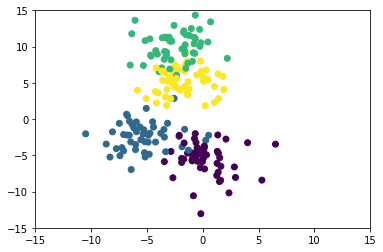

In [17]:
# create blobs
data = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=2, random_state=50)

# create np array for data points
points = data[0]

# create scatter plot
plt.scatter(data[0][:,0], data[0][:,1], c=data[1], cmap='viridis')
plt.xlim(-15,15)
plt.ylim(-15,15)
plt.show()

## Kmeans clustering
Kmeans clustering is the fist clustering approach most data scientists take. It groups your data into k clusters, where k is a paramter chosen by the researcher. There are different computational approaches, but they all start by calculating the average distance across rows in your dataset. 

In [3]:
# import KMeans
from sklearn.cluster import KMeans

# create kmeans object
kmeans = KMeans(n_clusters=4)
# fit kmeans object to data
kmeans.fit(points)
# print location of clusters learned by kmeans object
print(kmeans.cluster_centers_)
# save new clusters for chart
y_km = kmeans.fit_predict(points)

[[-7.89054437 -1.41346529]
 [ 1.51094799  1.60537373]
 [-2.41841652 10.3854814 ]
 [ 0.19564197 -7.79734722]]


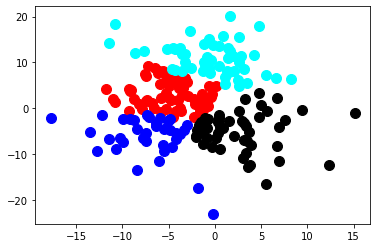

In [4]:
plt.scatter(points[y_km ==0,0], points[y_km == 0,1], s=100, c='red')
plt.scatter(points[y_km ==1,0], points[y_km == 1,1], s=100, c='black')
plt.scatter(points[y_km ==2,0], points[y_km == 2,1], s=100, c='blue')
plt.scatter(points[y_km ==3,0], points[y_km == 3,1], s=100, c='cyan')
plt.show()

# Finding the optimal K
How do we figure out the best number of clusters for our application? We usually use an elbow graph. Because K-means is easy to run we can iterate over multiple K's and calculate the average distances each time. We are looking for a number of clusters where additional groups generate little improvement in distance. 

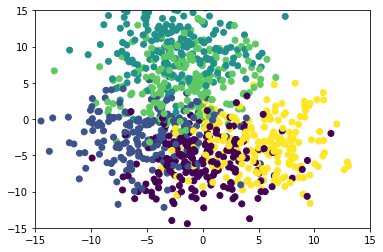

In [20]:
# create blobs
data = make_blobs(n_samples=1000, n_features=2, centers=5, cluster_std=3.5, random_state=50)

# create np array for data points - Call it X
X = data[0]

# create scatter plot
plt.scatter(data[0][:,0], data[0][:,1], c=data[1], cmap='viridis')
plt.xlim(-15,15)
plt.ylim(-15,15)
plt.show()



This is the  2  time through the cluserting loop
This is the  3  time through the cluserting loop
This is the  4  time through the cluserting loop
This is the  5  time through the cluserting loop
This is the  6  time through the cluserting loop
This is the  7  time through the cluserting loop
This is the  8  time through the cluserting loop
This is the  9  time through the cluserting loop
This is the  10  time through the cluserting loop
This is the  11  time through the cluserting loop
This is the  12  time through the cluserting loop
This is the  13  time through the cluserting loop
This is the  14  time through the cluserting loop
This is the  15  time through the cluserting loop
This is the  16  time through the cluserting loop
This is the  17  time through the cluserting loop
This is the  18  time through the cluserting loop
This is the  19  time through the cluserting loop
This is the  20  time through the cluserting loop
This is the  21  time through the cluserting loop
This is 

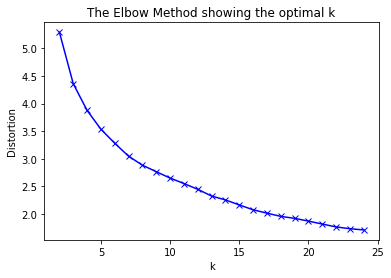

In [21]:
from scipy.spatial.distance import cdist   # to calculate distance and evaluate cluster fit

distortions = []
K = range(2,25)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X)
    print("This is the ", k," time through the cluserting loop")
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0])

    
# Plot the elbow
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()


# Problems with Kmeans clustering
The K-Means clustering method requires two major assumptions regarding the clusters:
1. Clusters are spherical - groups of observations are 'close' to each other when graphed in two dimenions 
2. Clusters are of similar size - approximately equal number of observations across clusters

## Incorrect number of clusters
If the data scientist chooses the wrong number of clusters we might get misleading groupings. There is no perfect way to pick the number of clusters, but we often use trial and error. The problem becomes more difficult when we have more than two variables and cannot easily graph the data.


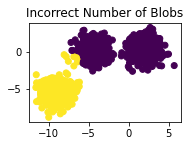

In [7]:
n_samples = 1500
random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

# Incorrect number of clusters
y_pred = KMeans(n_clusters=2, random_state=random_state).fit_predict(X)

plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Incorrect Number of Blobs")
#%matplotlib notebook
plt.show()

## Anisotropicly distributed data 
The clusters are not round. If the clusters are not round with distinct edges, separating the groups is arbitrary. 


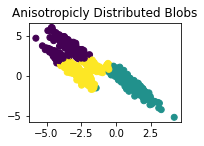

In [8]:
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_aniso)

plt.subplot(222)
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
plt.title("Anisotropicly Distributed Blobs")
plt.show()

## Different variance across groups
If some groups are tightly clustered while others have high variance, k-means will have trouble distingusing. The algorithm may assign the high variance group to multiple low variance groups.

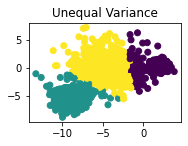

In [9]:
# Different variance
X_varied, y_varied = make_blobs(n_samples=n_samples,
                                cluster_std=[1.0, 2.5, 0.5],
                                random_state=random_state)
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_varied)

plt.subplot(223)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
plt.title("Unequal Variance")
plt.show()


## Unevenly sized blobs
The K-means algorithm does not force the blobs to have the same number of observations. This means that outliers may end up by themselves in a cluster. That reduces the number of clusters available for the rest of the dataset in ways that may be undesireable. 

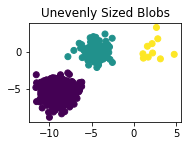

In [10]:
# Unevenly sized blobs
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))
y_pred = KMeans(n_clusters=3,
                random_state=random_state).fit_predict(X_filtered)

plt.subplot(224)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.title("Unevenly Sized Blobs")

plt.show()

# Agglomerative Clustering
Agglomerative clustering algorithms start with each point in its own cluster. They then merge the two closest clusters. They repeat this process until all points are in a single cluster. 

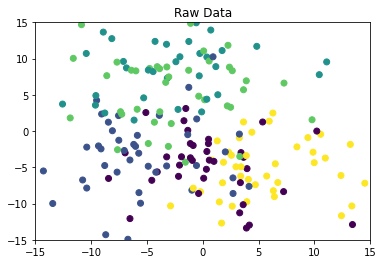

In [11]:
# Import packages and create the raw data. Keep sample size relatively small

from time import time
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# create a SMALL data set
data = make_blobs(n_samples=200, n_features=2, centers=5, cluster_std=5.0, random_state=50)
# create np array for data points - Call it X
X = data[0]
# create scatter plot
plt.scatter(data[0][:,0], data[0][:,1], c=data[1], cmap='viridis')
plt.xlim(-15,15)
plt.ylim(-15,15)
plt.title('Raw Data')
plt.show()  

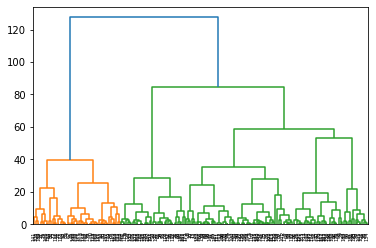

ward :	1.07s


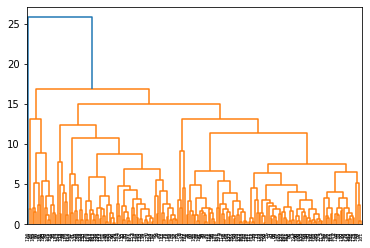

average :	1.14s


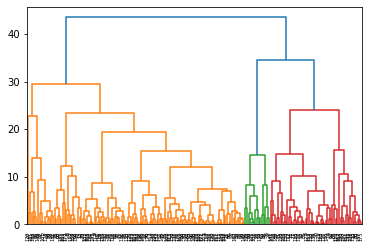

complete :	1.09s


In [12]:
# Print the dendrogram for three different linkage types

for linkage in ('ward', 'average', 'complete' ):
    t0 = time()
    hc = AgglomerativeClustering(linkage=linkage, n_clusters=3)
    Z = sch.linkage(X, linkage)
    plt.figure()
    dn = sch.dendrogram(Z)
    plt.show()
    print("%s :\t%.2fs" % (linkage, time() - t0))

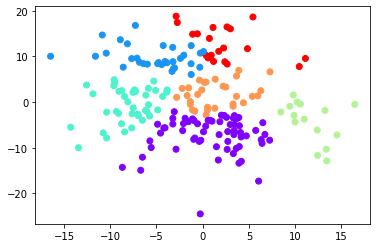

ward :	0.05s


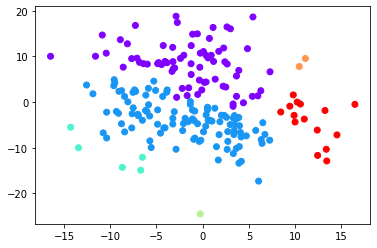

average :	0.04s


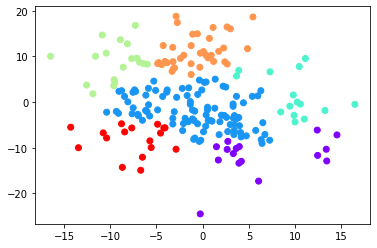

complete :	0.04s


In [13]:
# Now print out the clusters for the same three linkage types 
for linkage in ('ward', 'average', 'complete' ):
    t0 = time()
    hc = AgglomerativeClustering(linkage=linkage, n_clusters=6)
    hc.fit(X)
    plt.scatter(X[:,0],X[:,1], c=hc.labels_, cmap='rainbow')
    plt.show()
    print("%s :\t%.2fs" % (linkage, time() - t0))